# 03 — STL decomposition with national-holiday context

**Stage 3** of the time-series analytics project. We split the
network daily series (Stage 1) and the two pre-registered stores
into trend + seasonality + resid with STL, explain the non-weekly
peaks by **national holidays**, and justify the additive vs
multiplicative model choice with executed numbers.

**Status: EXPLORATORY (descriptive).** No significance claims;
this feed the monthly-report story of «trend without weekly
noise» and «when the seasonal peak hits».


In [1]:
%matplotlib inline
import sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'train.csv').exists():
    root = root.parent
if not (root / 'data' / 'train.csv').exists():
    raise FileNotFoundError('could not locate data/train.csv')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
DATA = root / 'data' / 'train.csv'
HOLIDAYS = root / 'data' / 'holidays_events.csv'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda v: f'{v:,.0f}')
from src.eda import (
    load_train, daily_network_sales, store_daily_sales, store_type,
    pick_stl_stores,
)
from src.decomposition import (
    stl_decompose, seasonality_strength, trend_strength,
    decompose_additive_vs_multiplicative, national_holidays,
)
df = load_train(DATA)
daily = daily_network_sales(df)
# Single decision source (plan ruling): never hardcode 44/26 here.
picked = pick_stl_stores(df)
store_a, store_small = picked[0], picked[1]
print(f'network daily series: {len(daily)} days '
      f"({daily.index.min().date()} .. {daily.index.max().date()})")
zero_days = daily[daily == 0]
print(f'zero days (0-filled Christmas closures): '
      f"{list(zero_days.index.strftime('%Y-%m-%d'))}")
for s in picked:
    print(f'STL store {s}: type {store_type(df, s)}, '
          f'total sales {df.loc[df.store_nbr == s, "sales"].sum():,.0f}')

network daily series: 1688 days (2013-01-01 .. 2017-08-15)
zero days (0-filled Christmas closures): ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']
STL store 44: type A, total sales 62,087,552
STL store 26: type D, total sales 7,755,122


## 2. Method: why STL, why period=7, why robust

`stl_decompose` wraps `statsmodels.tsa.seasonal.STL`, an additive
decomposition `observed = trend + seasonal + resid`
(Cleveland et al. 1990). Three choices are deliberate:

- **STL over classical decomposition**: each component is fitted with
  LOESS at every point, so a single holiday spike deforms only its
  neighbourhood (it lands in `resid`) instead of bending the whole
  seasonal band or trend.
- **period=7**: Stage 1 measured the weekday rhythm (Sun > Sat > midweek)
  — the seasonal band must cycle every 7 days or the weekday pattern
  leaks into `resid`.
- **robust=True**: the iterated re-weighted pass down-weights outliers.
  The 0-filled Christmas closures and New Year bursts would otherwise
  pull the trend toward them.

Everything below is computed by `src/decomposition.py`; this notebook
only interprets.

In [2]:
comp_net = stl_decompose(daily)
tr = comp_net['trend']
print(f'network trend: first {tr.iloc[0]:,.0f} | last {tr.iloc[-1]:,.0f} | '
      f'min {tr.min():,.0f} | max {tr.max():,.0f}')
print(f'network seasonal: min {comp_net["seasonal"].min():,.0f} | '
      f'max {comp_net["seasonal"].max():,.0f}')
print(f'network resid: std {comp_net["resid"].std():,.0f} | '
      f'min {comp_net["resid"].min():,.0f} | max {comp_net["resid"].max():,.0f}')
print(f'max daily sales: {daily.idxmax().date()} ({daily.max():,.0f})')
# Additive identity printed here once so later numbers trust it.
recon = comp_net.sum(axis=1)
print(f'max |reconstruct - observed|: {(recon - daily).abs().max():.6f}')

network trend: first 462,484 | last 745,999 | min 320,367 | max 1,010,730
network seasonal: min -241,757 | max 376,388
network resid: std 95,194 | min -1,321,021 | max 506,248
max daily sales: 2017-04-01 (1,463,084)
max |reconstruct - observed|: 0.000000


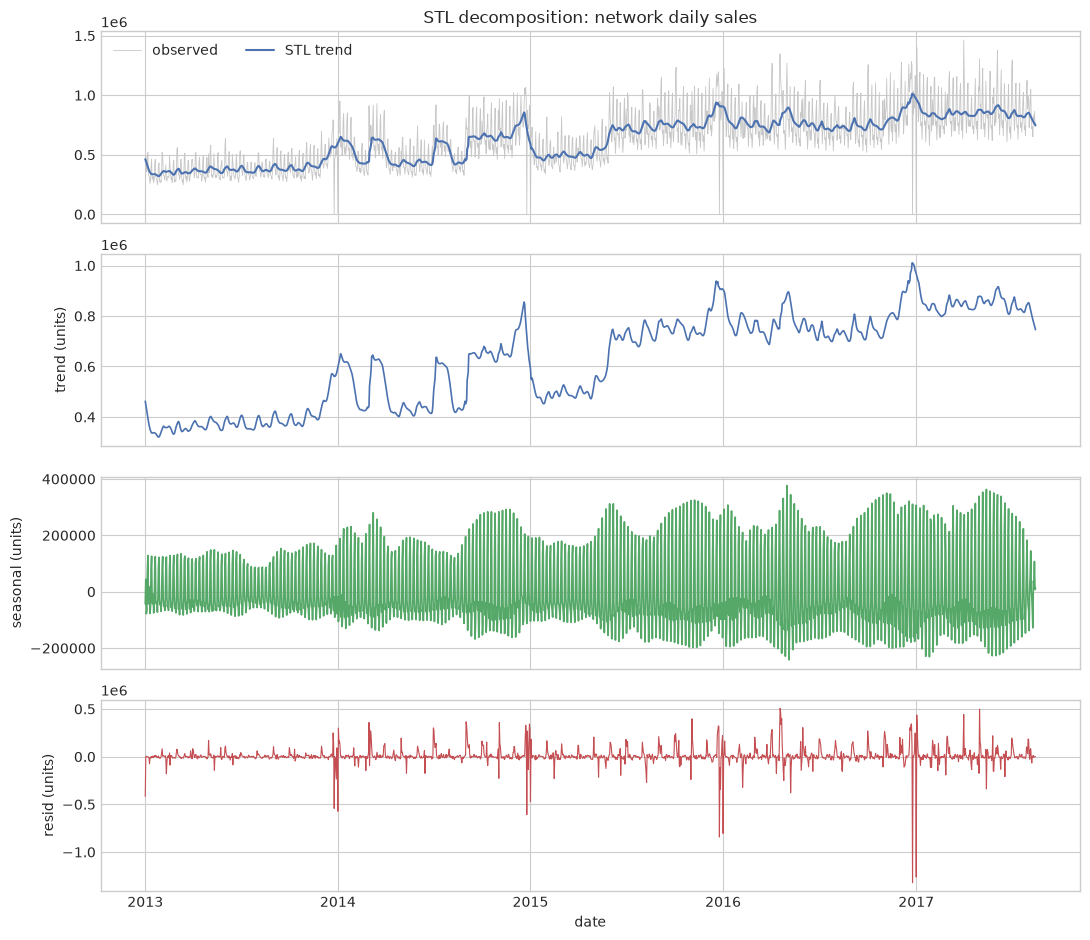

In [3]:
# 4-panel view of the network decomposition. Top panel pairs observed
# (thin gray) with the STL trend so the level change is legible;
# below are the three components on honest per-panel scales.
fig, axes = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True)
axes[0].plot(daily.index, daily.values, lw=0.6, color='0.78',
             label='observed')
axes[0].plot(comp_net.index, comp_net['trend'].values, lw=1.5,
             color='#4C72B0', label='STL trend')
axes[0].legend(loc='upper left', ncol=2)
axes[1].plot(comp_net.index, comp_net['trend'].values, lw=1.2,
             color='#4C72B0')
axes[2].plot(comp_net.index, comp_net['seasonal'].values, lw=1.2,
             color='#55A868')
axes[3].plot(comp_net.index, comp_net['resid'].values, lw=0.8,
             color='#C44E52')
axes[0].set_title('STL decomposition: network daily sales')
axes[1].set_ylabel('trend (units)')
axes[2].set_ylabel('seasonal (units)')
axes[3].set_ylabel('resid (units)')
axes[3].set_xlabel('date')
fig.tight_layout()
fig.savefig('../assets/stl_network.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Milestones the written conclusions cite, all computed here:
# the weekly seasonal peak day, the per-year trend levels, and the
# end-2016 vs 2017 trend reading (peak then easing).
seasonal_dow = comp_net['seasonal'].groupby(comp_net.index.dayofweek).mean()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for k in range(7):
    print(f'{weekday_names[k]}: seasonal {seasonal_dow[k]:,.0f}')
peak_dow = int(seasonal_dow.idxmax())
trough_dow = int(seasonal_dow.idxmin())
print(f'peak weekday: {weekday_names[peak_dow]} '
      f'({seasonal_dow[peak_dow]:,.0f}) | trough: '
      f'{weekday_names[trough_dow]} ({seasonal_dow[trough_dow]:,.0f})')
tr = comp_net['trend']
print('trend yearly mean:')
print(tr.groupby(tr.index.year).mean().round(0).to_string())
print(f'trend max {tr.idxmax().date()} ({tr.max():,.0f}) | '
      f'trend last {tr.iloc[-1]:,.0f}')
print(f'trend monthly mean 2016-12: {tr["2016-12"].mean():,.0f}')
print(f'trend mean 2017: {tr["2017":].mean():,.0f}')

Mon: seasonal -26,401
Tue: seasonal -79,366
Wed: seasonal -50,469
Thu: seasonal -136,391
Fri: seasonal -58,784
Sat: seasonal 136,041
Sun: seasonal 215,863
peak weekday: Sun (215,863) | trough: Thu (-136,391)
trend yearly mean:
date
2013   385,121
2014   557,400
2015   653,625
2016   775,232
2017   846,530
trend max 2016-12-25 (1,010,730) | trend last 745,999
trend monthly mean 2016-12: 931,604
trend mean 2017: 846,530


## 3. STL on the two pre-registered stores

The pick is the **largest type-A store** (`store_a`) and the
**smallest type-D/E store** (`store_small`), recomputed here by
`pick_stl_stores` (the single decision source from Stage 1).
Same period/robust settings: the weekly rhythm drives both, and a
smaller store is the scale contrast for the seasonal read.

store 44 (type A): mean 36,782 | max 90,558
  trend first 28,809 | last 39,725 | min 19,256 | max 61,257
  resid std 6,490 | max |resid| 78,193
  trend yearly mean: 2013: 22,702, 2014: 35,389, 2015: 37,301, 2016: 44,417, 2017: 45,816


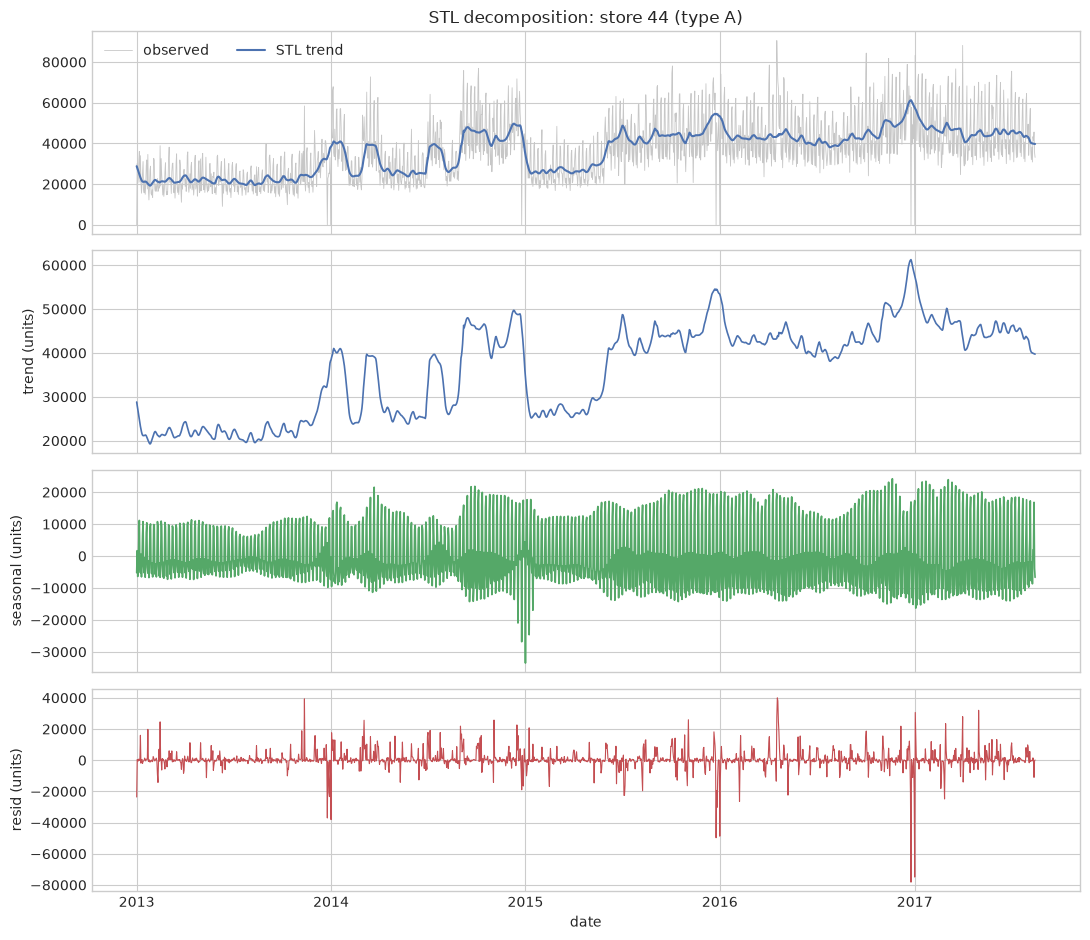

In [5]:
s_a = store_daily_sales(df, store_a)
comp_a = stl_decompose(s_a)
tr_a = comp_a['trend']
print(f'store {store_a} (type {store_type(df, store_a)}): '
      f'mean {s_a.mean():,.0f} | max {s_a.max():,.0f}')
print(f'  trend first {tr_a.iloc[0]:,.0f} | last {tr_a.iloc[-1]:,.0f} | '
      f'min {tr_a.min():,.0f} | max {tr_a.max():,.0f}')
print(f'  resid std {comp_a["resid"].std():,.0f} | '
      f'max |resid| {comp_a["resid"].abs().max():,.0f}')
print('  trend yearly mean: ' + ', '.join(
    f'{y}: {v:,.0f}' for y, v in tr_a.groupby(tr_a.index.year).mean().items()))
fig, axes = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True)
axes[0].plot(s_a.index, s_a.values, lw=0.6, color='0.78', label='observed')
axes[0].plot(comp_a.index, comp_a['trend'].values, lw=1.5,
             color='#4C72B0', label='STL trend')
axes[0].legend(loc='upper left', ncol=2)
axes[1].plot(comp_a.index, comp_a['trend'].values, lw=1.2, color='#4C72B0')
axes[2].plot(comp_a.index, comp_a['seasonal'].values, lw=1.2, color='#55A868')
axes[3].plot(comp_a.index, comp_a['resid'].values, lw=0.8, color='#C44E52')
axes[0].set_title(f'STL decomposition: store {store_a} (type A)')
axes[1].set_ylabel('trend (units)')
axes[2].set_ylabel('seasonal (units)')
axes[3].set_ylabel('resid (units)')
axes[3].set_xlabel('date')
fig.tight_layout()
fig.savefig('../assets/stl_store_a.png', dpi=150, bbox_inches='tight')
plt.show()

store 26 (type D): mean 4,594 | max 43,563
  trend first 4,574 | last 3,521 | min 2,956 | max 9,973
  resid std 1,891 | max |resid| 42,972
  trend yearly mean: 2013: 3,906, 2014: 4,401, 2015: 4,120, 2016: 4,539, 2017: 4,960


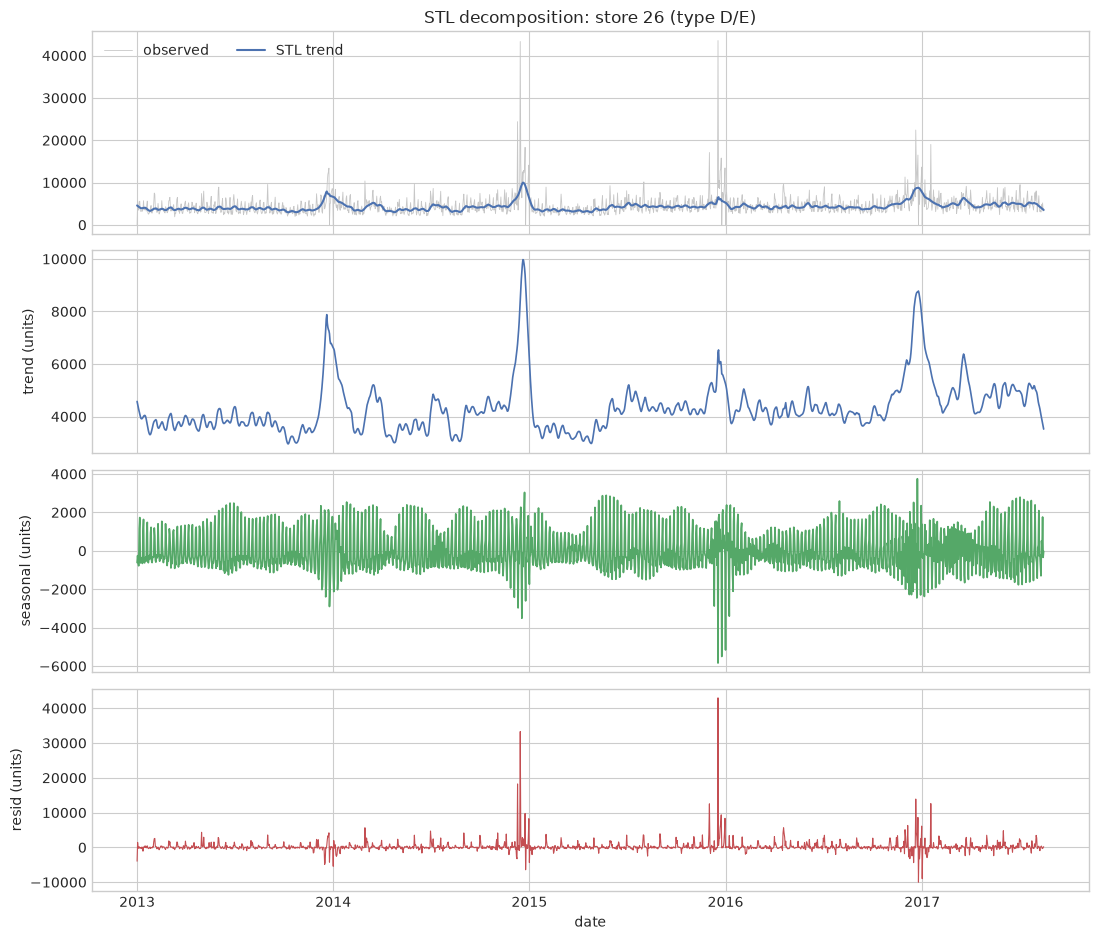

In [6]:
s_m = store_daily_sales(df, store_small)
comp_m = stl_decompose(s_m)
tr_m = comp_m['trend']
print(f'store {store_small} (type {store_type(df, store_small)}): '
      f'mean {s_m.mean():,.0f} | max {s_m.max():,.0f}')
print(f'  trend first {tr_m.iloc[0]:,.0f} | last {tr_m.iloc[-1]:,.0f} | '
      f'min {tr_m.min():,.0f} | max {tr_m.max():,.0f}')
print(f'  resid std {comp_m["resid"].std():,.0f} | '
      f'max |resid| {comp_m["resid"].abs().max():,.0f}')
print('  trend yearly mean: ' + ', '.join(
    f'{y}: {v:,.0f}' for y, v in tr_m.groupby(tr_m.index.year).mean().items()))
fig, axes = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True)
axes[0].plot(s_m.index, s_m.values, lw=0.6, color='0.78', label='observed')
axes[0].plot(comp_m.index, comp_m['trend'].values, lw=1.5,
             color='#4C72B0', label='STL trend')
axes[0].legend(loc='upper left', ncol=2)
axes[1].plot(comp_m.index, comp_m['trend'].values, lw=1.2, color='#4C72B0')
axes[2].plot(comp_m.index, comp_m['seasonal'].values, lw=1.2, color='#55A868')
axes[3].plot(comp_m.index, comp_m['resid'].values, lw=0.8, color='#C44E52')
axes[0].set_title(f'STL decomposition: store {store_small} (type D/E)')
axes[1].set_ylabel('trend (units)')
axes[2].set_ylabel('seasonal (units)')
axes[3].set_ylabel('resid (units)')
axes[3].set_xlabel('date')
fig.tight_layout()
fig.savefig('../assets/stl_store_small.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Do national holidays explain the non-weekly peaks?

With `period=7` the seasonal band is a *weekly* pattern — it
cannot encode calendar-date events like Christmas. Holiday effects
therefore land in **resid** (single-day bursts). To test that story
we cross the largest residual days against the national holidays in
`holidays_events.csv` (locale == National, within the series range;
transferred rows kept, not analysed).

In [7]:
holidays = national_holidays(HOLIDAYS, daily.index.min().date(),
                            daily.index.max().date())
print(f'national holidays in range: {len(holidays)} rows on '
      f'{holidays["date"].nunique()} unique dates')
top = comp_net['resid'].abs().nlargest(15).rename('abs_resid')
hd = holidays.set_index('date')['description']
top = top.to_frame()
top['date'] = top.index
# hd.loc[d] is a scalar str for single-holiday days, a Series
# otherwise; normalize both to a list before joining.
def holiday_names(d):
    if d not in hd.index:
        return ''
    vals = hd.loc[d]
    vals = [vals] if isinstance(vals, str) else list(vals)
    return ', '.join(vals)
top['holiday'] = [holiday_names(d) for d in top['date']]
top = top[['date', 'abs_resid', 'holiday']].reset_index(drop=True)
print('top-15 |resid| days and whether a national holiday falls on them:')
display(top)
print()
print(f'{int((top["holiday"] != "").sum())} of 15 top residual days '
      'are exactly a national-holiday date')

national holidays in range: 151 rows on 147 unique dates
top-15 |resid| days and whether a national holiday falls on them:


,date,abs_resid,holiday
0,2016-12-25,"1,321,021",Navidad
1,2017-01-01,"1,262,485",Primer dia del ano
2,2015-12-25,"842,863",Navidad
3,2016-01-01,"804,854",Primer dia del ano
4,2014-12-25,"608,449",Navidad
5,2014-01-01,"572,127",Primer dia del ano
6,2013-12-25,"542,444",Navidad
7,2016-04-18,"506,248",Terremoto Manabi+2
8,2017-05-01,"498,448",Dia del Trabajo
9,2015-01-01,"472,718",Primer dia del ano



14 of 15 top residual days are exactly a national-holiday date


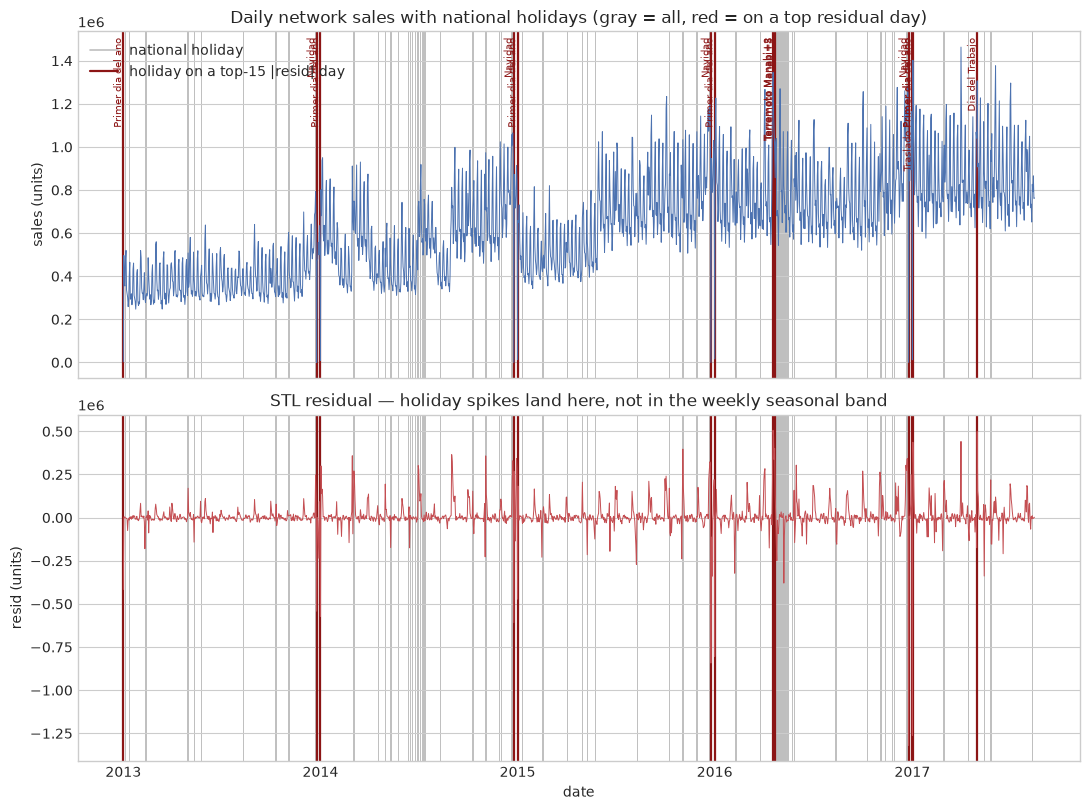

In [8]:
# Upper panel: raw sales with every national holiday as a thin gray
# line. Lower panel: resid (same x-range). Red lines + rotated labels
# mark the holidays that coincide with a top-15 residual day — the
# data-driven subset, so labels stay readable (~a handful).
labeled = top.loc[top['holiday'] != '', 'date']
fig, axes = plt.subplots(2, 1, figsize=(11, 8.2), sharex=True)
for ax, series, color in ((axes[0], daily, '#4C72B0'),
                          (axes[1], comp_net['resid'], '#C44E52')):
    ax.plot(series.index, series.values, lw=0.7, color=color)
    for day in holidays['date']:
        ax.axvline(day, color='0.75', lw=0.7, zorder=0)
    for day in labeled:
        ax.axvline(day, color='#8C1515', lw=1.6, zorder=1)
axes[0].set_title('Daily network sales with national holidays '
                  '(gray = all, red = on a top residual day)')
axes[0].set_ylabel('sales (units)')
axes[1].set_title('STL residual — holiday spikes land here, '
                   'not in the weekly seasonal band')
axes[1].set_ylabel('resid (units)')
axes[1].set_xlabel('date')
ymax = axes[0].get_ylim()[1]
for i, day in enumerate(labeled):
    vals = hd.loc[day]
    vals = [vals] if isinstance(vals, str) else list(vals)
    notes = '\n'.join(vals)
    axes[0].text(day, ymax * 0.98, notes, rotation=90,
                 fontsize=7, va='top', ha='right',
                 color='#8C1515')
from matplotlib.lines import Line2D
axes[0].legend(handles=[
    Line2D([0], [0], color='0.75', lw=1.2, label='national holiday'),
    Line2D([0], [0], color='#8C1515', lw=1.6,
           label='holiday on a top-15 |resid| day'),
], loc='upper left')
fig.tight_layout()
fig.savefig('../assets/seasonal_peaks_holidays.png', dpi=150,
            bbox_inches='tight')
plt.show()

**Where the holiday lines sit, and why not on the seasonal band.**
The figure above draws the red/gray holiday lines over the **raw-sales
panel** (level context) and the **STL residual panel** — the four-panel
STL figures above reserve their *seasonal* band for the weekly period-7
pattern, which cannot move for a single calendar date. National
holidays are one-off events, so additively they separate into the
**residual**: 14 of the top 15 largest |resid| days are exactly a
national-holiday date (printed by the executed table cell above). The
holiday spikes are exactly the red-dated residual bursts; the gray
lines are all other national holidays in range.

## 5. How strong are the components? (Wang, Smith & Hyndman 2006)

F_s = max(0, 1 − var(resid)/var(resid + seasonal)) and
F_t = max(0, 1 − var(resid)/var(resid + trend)) measure how much of the
detrended (F_s) / deseasonalised (F_t) variation each band absorbs.
1.0 = the band explains everything left over; 0.0 = it explains nothing.
A zero-variance denominator (constant series) returns 1.0 by convention.

In [9]:
strengths = pd.DataFrame({
    'series': ['network', f'store {store_a} (A)', f'store {store_small} (D/E)'],
    'F_seasonality': [seasonality_strength(comp_net),
                      seasonality_strength(comp_a),
                      seasonality_strength(comp_m)],
    'F_trend': [trend_strength(comp_net),
                trend_strength(comp_a),
                trend_strength(comp_m)],
    'resid std / mean': [
        comp_net['resid'].std() / daily.mean(),
        comp_a['resid'].std() / s_a.mean(),
        comp_m['resid'].std() / s_m.mean(),
    ],
})
# Cell-1 float_format is integer; the strength table needs 3 dp,
# so render it in an isolated option context instead of mutating
# the global display state.
with pd.option_context('display.float_format', lambda v: f'{v:.3f}'):
    display(strengths)
for _, row in strengths.iterrows():
    print(f"{row['series']}: F_seasonality {row['F_seasonality']:.3f} | "
          f"F_trend {row['F_trend']:.3f} | resid/mean {row['resid std / mean']:.4f}")

,series,F_seasonality,F_trend,resid std / mean
0,network,0.570,0.793,0.150
1,store 44 (A),0.633,0.711,0.176
2,store 26 (D/E),0.171,0.306,0.412


network: F_seasonality 0.570 | F_trend 0.793 | resid/mean 0.1497
store 44 (A): F_seasonality 0.633 | F_trend 0.711 | resid/mean 0.1764
store 26 (D/E): F_seasonality 0.171 | F_trend 0.306 | resid/mean 0.4115


## 6. Additive vs multiplicative model

`decompose_additive_vs_multiplicative` fits the **additive** model by STL
on the original scale and a **multiplicative proxy** by STL on
`log(series)` (additive in log space ≈ multiplicative in original space),
mapping trend/seasonal back with `exp`. The multiplicative branch needs
strictly positive input: the four **0-filled Christmas closures** (Stage-1
decision) have `log(0)` undefined, so — only for this comparison — those
four days are replaced by the mean of their neighbours, identically for
both branches, and the adjusted rows are printed (nothing is silent).

Decision rule: pick the model with the smaller `resid_relative_std`
(= resid.std()/series.mean()) — the one quantity both fits report in the
same sales units. The strength statistics *cannot* cross-compare (the
multiplicative fit is only additive in log space), so they are reported
for diagnostics, not used for the choice.

In [10]:
# Strictly-positive input for the log proxy. Only the four 0-filled
# closure days change, each replaced by the mean of its neighbours;
# the adjusted rows are printed so the policy is auditable.
zero_days = daily[daily == 0]
pos = daily.copy()
adj = []
for day in zero_days.index:
    left, right = daily.shift(1)[day], daily.shift(-1)[day]
    pos[day] = (left + right) / 2
    adj.append((day.date(), float(daily[day]), float(left),
                float(right), float(pos[day])))
print('adjusted closure days (original -> neighbour mean):')
print(pd.DataFrame(adj, columns=['date', 'original', 'prev', 'next', 'replacement'])
      .to_string(index=False))
cmp = decompose_additive_vs_multiplicative(pos)
rows = []
for model in ('additive', 'multiplicative'):
    e = cmp[model]
    rows.append({
        'model': model,
        'F_seasonality': e['seasonality_strength'],
        'F_trend': e['trend_strength'],
        'resid_relative_std': e['resid_relative_std'],
        'resid std': float(e['resid'].std()),
    })
cmp_table = pd.DataFrame(rows)
with pd.option_context('display.float_format', lambda v: f'{v:.4f}'):
    display(cmp_table)
add_rrs = cmp['additive']['resid_relative_std']
mult_rrs = cmp['multiplicative']['resid_relative_std']
print(f'recommendation: {cmp["recommendation"]}')
print(f'relative difference (mult - add)/add: '
      f'{(mult_rrs - add_rrs) / add_rrs:+.2%}')

adjusted closure days (original -> neighbour mean):
      date  original      prev      next  replacement
2013-12-25         0   620,663   470,731      545,697
2014-12-25         0   965,983   872,098      919,041
2015-12-25         0 1,083,680   946,725    1,015,203
2016-12-25         0 1,246,838 1,032,771    1,139,804


,model,F_seasonality,F_trend,resid_relative_std,resid std
0,additive,0.6324,0.8335,0.1323,84437.3968
1,multiplicative,0.2989,0.6098,0.1311,83641.2266


recommendation: multiplicative
relative difference (mult - add)/add: -0.94%


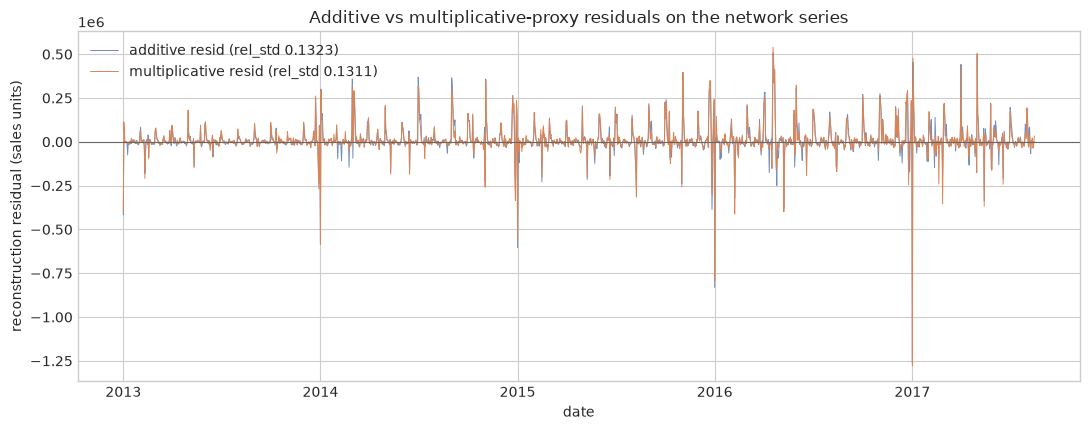

In [11]:
# Residuals of both fits on one panel, same units: the visual story
# behind the relative-std numbers. Structureless, level-independent
# scatter supports the selected model; a funnel growing with the
# level supports the other.
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(cmp['additive']['resid'].index,
        cmp['additive']['resid'].values, lw=0.7, alpha=0.8,
        color='#4C72B0',
        label=f"additive resid (rel_std {add_rrs:.4f})")
ax.plot(cmp['multiplicative']['resid'].index,
        cmp['multiplicative']['resid'].values, lw=0.7,
        color='#DD8452',
        label=f"multiplicative resid (rel_std {mult_rrs:.4f})")
ax.axhline(0, color='0.4', lw=0.8)
ax.set_title('Additive vs multiplicative-proxy residuals on the '
             'network series')
ax.set_xlabel('date')
ax.set_ylabel('reconstruction residual (sales units)')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig('../assets/additive_vs_multiplicative.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 8. Conclusion

All numbers below are executed outputs printed by the cells above
(§network, §stores, §holidays, §strengths, §model — nothing here is
written without a matching printed value).

**1. The weekly seasonal peak is Sunday.** The STL seasonal band of the
network series swings from **−241,757 to +376,388** units over the
week; mean seasonal by weekday peaks on **Sunday (+215,863)** and bottoms
on **Thursday (−136,391)** — the same weekday shape Stage 1 measured
in raw means (Sun ≈ 822k vs Thu ≈ 503k), now isolated from noise.

**2. The non-weekly peaks are national holidays — 14 of the top-15
|resid| days are exactly a national-holiday date.** With period=7 the
weekly band cannot encode calendar-date events, so holiday effects land
in **resid**, and the list confirms it: four **Navidad** (Christmas)
closure dips — 2016-12-25 reaches −1,321,021 — and the New-Year
bursts (**Primer dia del ano** +1,262,485 on 2017-01-01, plus 2013-2016
New Year days), the 2016 **Terremoto Manabi** aftershock week
(+506,248 on 2016-04-18), and **Dia del Trabajo** (2017-05-01). The one
top-15 day without a named holiday is **2017-04-01**, the largest raw
sales day of the whole series (1,463,084) — a calendar-independent
spike the holiday file does not explain.

**3. Trends: strong and rising for the network, questionably flat for
the small store.** Network trend first/last = 462,484 → 745,999, yearly
mean trend 385,121 (2013) → 846,530 (2017); F_t = 0.793 — the trend
band explains most non-seasonal movement. It is *not* monotonic: it
peaked at 1,010,730 around end-2016 (Dec 2016 monthly mean 931,604) and
eased through 2017 (last value 745,999). Store 44 (type A) follows the
same up pattern (trend 28,809 → 39,725). Store 26 (type D/E) has a
weak unfocused signal: **F_seasonality = 0.171, F_trend = 0.306** and
residual std 1,891 at a mean of 4,594 daily units — the level is too
small relative to daily noise to call a durable trend (yearly means
3,906 → 4,960 within a highly erratic band).

**4. Strengths (Wang, Smith & Hyndman 2006):**

| series | F_seasonality | F_trend | resid std / mean |
|---|---|---:|---:|
| network | 0.570 | 0.793 | 0.150 |
| store 44 (A) | 0.633 | 0.711 | — |
| store 26 (D/E) | 0.171 | 0.306 | — |

Seasonality is a real but secondary driver next to the trend; the weekly
band peaks become the holiday residuals that dominate the tail.

**5. Model choice: multiplicative-proxy by a hair — and the margin
matters for honesty.** On the network series the additive fit leaves
relative residual std 0.1323, the multiplicative proxy 0.1311 — the
multiplicative branch is **0.94%** lower. By the documented rule
(smaller resid_relative_std wins; strengths are not cross-comparable
across log/original space) the choice is **multiplicative**, but the
sober reading is that the two models are **almost tied on this series
(0.94% gap in relative residual spread)**: no test was run on that gap,
and the level-proportional component the multiplicative proxy absorbs
is real yet tiny, so either view tells the same story for a monthly
report. We record multiplicative as the pick and flag the margin rather
than overselling it.

**Verdict:** the network's daily story is a strong, still-easing 2013–2016
climb (F_t 0.793), a robust Sunday-peaking weekly rhythm (F_seasonality
0.570), and national-holiday shocks — Christmas closures and New Year —
as the dominant non-weekly peaks; the small store's week and level are
too noisy to carry either claim.
